<img src="./Logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº3
#### Patricia González Todd

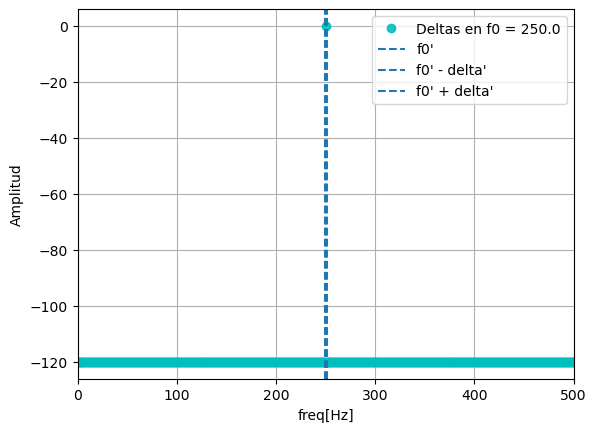

In [32]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    # Usamos np.arange(nn) para asegurar exactamente 'nn' muestras
    tt = np.arange(0, nn) * ts 
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph) 
    return tt, xx

def mi_funcion_ruido (tt, Pr):
    desvio = np.sqrt(Pr)
    r = np.random.normal(0, desvio, len(tt)) # lo del medio es el desvio estandar
    #verifico el valor de la varianza de r a ver si calcule bien
    return r

# Parámetros
A = np.sqrt(2) #varianza normalizada
dc = 0
fs = 1000
fase = 0
muestras = 1000 
deltaf = fs/muestras #delta f que es RESOLUCION ESPECTRAL
k0 = [(muestras/4),(muestras/4) + 1/4, (muestras/4) + 1/2]
f0 = k0[0]*deltaf 

tt, S = mi_funcion_sen(A, dc, f0, fase, muestras, fs) 

#S sintonizada
e_S = np.fft.fft(S)/(muestras/A)  # escalo para que me de donde yo quiero
mod_e_S = np.abs((e_S))**2

# paso a db
mod_e_S_db = 10*np.log10(mod_e_S + 1e-12) #db

ffreq = np.arange(0, muestras)*deltaf

# Gráfico SOLO DEL DELTA
#plt.figure(figsize=(10, 10))
plt.plot(ffreq, mod_e_S_db,'co', label= f"Deltas en f0 = {f0}", alpha = 0.9)

# línea vertical en x = 3
plt.axvline(x=(f0), linestyle = '--',label = "f0'")
plt.axvline(x=(f0 - deltaf), linestyle = '--',label = "f0' - delta'")
plt.axvline(x=(f0 + deltaf), linestyle = '--',label = "f0' + delta'")
plt.xlim(0, fs/2)
plt.legend()
plt.xlabel("freq[Hz]")
plt.ylabel("Amplitud")
plt.grid(0.01)
plt.show()


Ahora para desintosacion 1/4

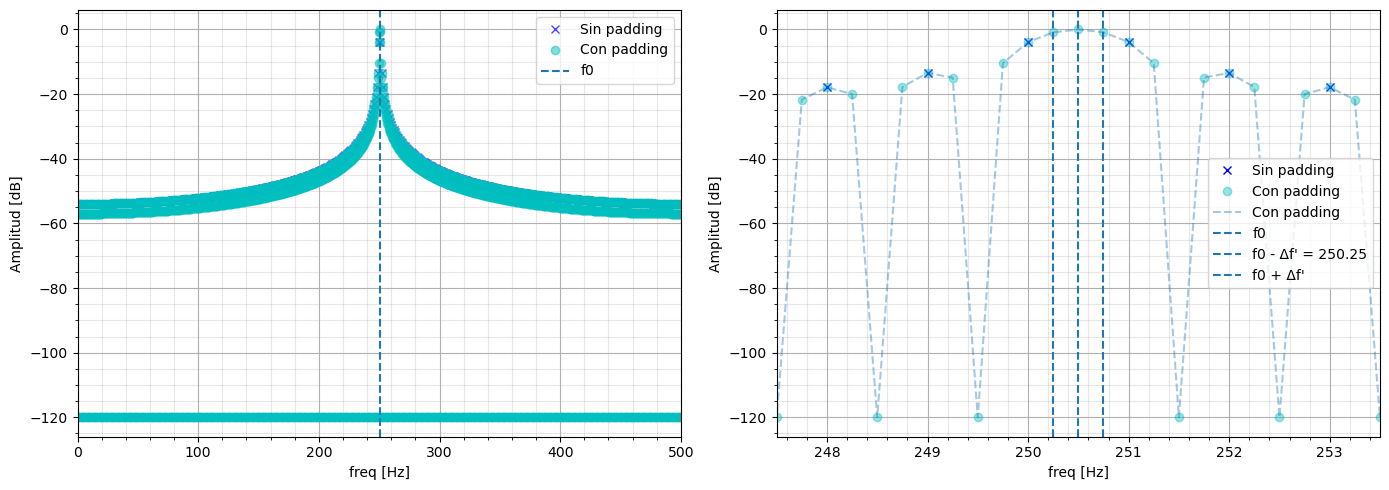

In [38]:
#%% Ahora con padding 1/4

# Parámetros
A = np.sqrt(2)
dc = 0
fs = 1000
fase = 0

muestras = 1000

deltaf = fs/muestras

k0 = [(muestras/4),
      (muestras/4) + 1/4,
      (muestras/4) + 1/2]

f0 = k0[2] * deltaf


# señal original
tt, S = mi_funcion_sen(A, dc, f0, fase, muestras, fs)


# ===== zero padding =====
ceros = np.zeros(3*1000)

S_p = np.concatenate([S, ceros])

muestrasp = len(S_p) #deberia ser 4000 ahora

deltafp = fs / muestrasp


# ===== FFT original =====
e_S = np.fft.fft(S) / (muestras / A)

mod_e_S = np.abs(e_S)**2

mod_e_S_db = 10 * np.log10(mod_e_S + 1e-12)


# ===== FFT padding =====
e_Sp = np.fft.fft(S_p) / (muestrasp / A)

mod_e_Sp = np.abs(e_Sp)**2

mod_e_Sp_norm = mod_e_Sp / np.max(mod_e_Sp)

mod_e_Sp_db = 10 * np.log10(mod_e_Sp_norm + 1e-12)


# ejes de frecuencia
ffreq = np.arange(0, muestras) * deltaf

ffreq_p = np.arange(0, muestrasp) * deltafp


# ===== figuras =====
fig, ax = plt.subplots(1, 2, figsize=(14, 5))


# ================= gráfico completo =================

ax[0].plot(ffreq,
           mod_e_S_db,'bx', label='Sin padding', alpha=0.7)

ax[0].plot(ffreq_p,
           mod_e_Sp_db,'co', label='Con padding', alpha=0.5)

ax[0].axvline(x=f0, linestyle='--', label='f0')

ax[0].set_xlim(0, fs/2)

ax[0].set_xlabel("freq [Hz]")
ax[0].set_ylabel("Amplitud [dB]")

ax[0].minorticks_on()

ax[0].grid(True, which='major')
ax[0].grid(True, which='minor', alpha=0.3)

ax[0].legend()


# ================= zoom =================

ax[1].plot(ffreq, mod_e_S_db, 'bx', label='Sin padding', alpha=1)

ax[1].plot(ffreq_p, mod_e_Sp_db, 'co', label='Con padding',  alpha=0.4)
ax[1].plot(ffreq_p, mod_e_Sp_db, '--', label='Con padding',  alpha=0.4)


ax[1].axvline(x=f0, linestyle='--', label='f0')
ax[1].axvline(x=f0 - deltafp, linestyle='--', label= f"f0 - Δf' = {f0 - deltafp}")
ax[1].axvline(x=f0 + deltafp, linestyle='--', label="f0 + Δf'")

ax[1].set_xlim(f0 - 3*deltaf, f0 + 3*deltaf)

ax[1].set_xlabel("freq [Hz]")
ax[1].set_ylabel("Amplitud [dB]")

ax[1].minorticks_on()

ax[1].grid(True, which='major')
ax[1].grid(True, which='minor', alpha=0.3)

ax[1].legend()


plt.tight_layout()
plt.show()

ahora desintinozacion 1/2

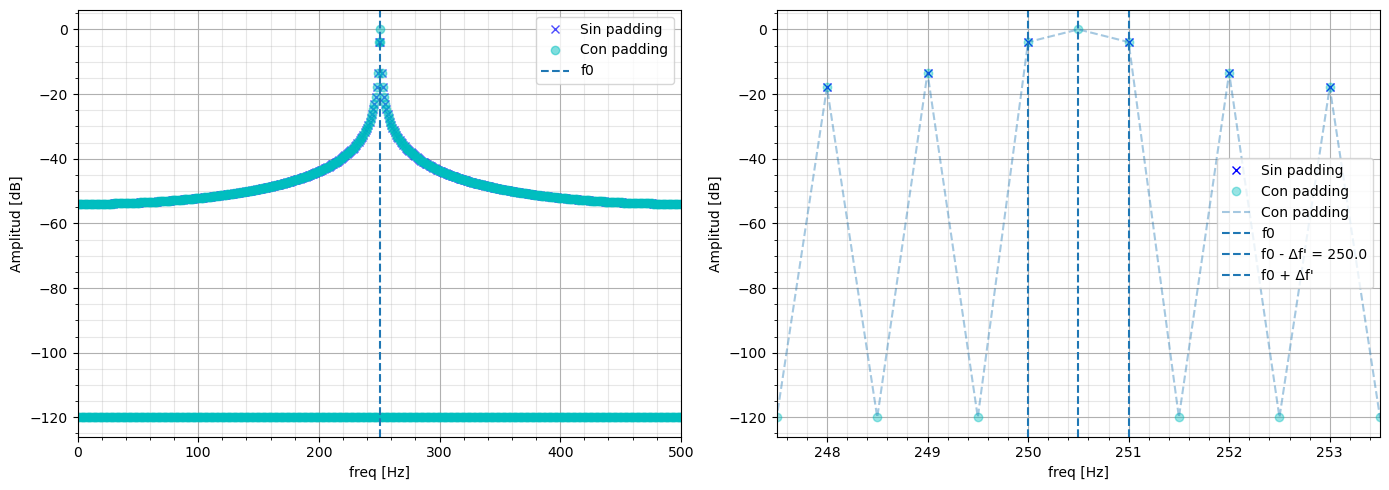

In [37]:
# Parámetros
A = np.sqrt(2)
dc = 0
fs = 1000
fase = 0

muestras = 1000

deltaf = fs/muestras

k0 = [(muestras/4),
      (muestras/4) + 1/4,
      (muestras/4) + 1/2]

f0 = k0[2] * deltaf


# señal original
tt, S = mi_funcion_sen(A, dc, f0, fase, muestras, fs)


# ===== zero padding =====
ceros = np.zeros(1000)

S_p = np.concatenate([S, ceros])

muestrasp = len(S_p)

deltafp = fs / muestrasp


# ===== FFT original =====
e_S = np.fft.fft(S) / (muestras / A)

mod_e_S = np.abs(e_S)**2

mod_e_S_db = 10 * np.log10(mod_e_S + 1e-12)


# ===== FFT padding =====
e_Sp = np.fft.fft(S_p) / (muestrasp / A)

mod_e_Sp = np.abs(e_Sp)**2

mod_e_Sp_norm = mod_e_Sp / np.max(mod_e_Sp) #normalizo con el maximo porque lo quiero devolver a 0db en su maximo

mod_e_Sp_db = 10 * np.log10(mod_e_Sp_norm + 1e-12)


# ejes de frecuencia
ffreq = np.arange(0, muestras) * deltaf

ffreq_p = np.arange(0, muestrasp) * deltafp


# ===== figuras =====
fig, ax = plt.subplots(1, 2, figsize=(14, 5))


# ================= gráfico completo =================

ax[0].plot(ffreq,
           mod_e_S_db,'bx', label='Sin padding', alpha=0.7)

ax[0].plot(ffreq_p,
           mod_e_Sp_db,'co', label='Con padding', alpha=0.5)

ax[0].axvline(x=f0, linestyle='--', label='f0')

ax[0].set_xlim(0, fs/2)

ax[0].set_xlabel("freq [Hz]")
ax[0].set_ylabel("Amplitud [dB]")

ax[0].minorticks_on()

ax[0].grid(True, which='major')
ax[0].grid(True, which='minor', alpha=0.3)

ax[0].legend()


# ================= zoom =================

ax[1].plot(ffreq, mod_e_S_db, 'bx', label='Sin padding', alpha=1)

ax[1].plot(ffreq_p, mod_e_Sp_db, 'co', label='Con padding',  alpha=0.4)
ax[1].plot(ffreq_p, mod_e_Sp_db, '--', label='Con padding',  alpha=0.4)


ax[1].axvline(x=f0, linestyle='--', label='f0')
ax[1].axvline(x=f0 - deltafp, linestyle='--', label= f"f0 - Δf' = {f0 - deltafp}")
ax[1].axvline(x=f0 + deltafp, linestyle='--', label="f0 + Δf'")

ax[1].set_xlim(f0 - 3*deltaf, f0 + 3*deltaf)

ax[1].set_xlabel("freq [Hz]")
ax[1].set_ylabel("Amplitud [dB]")

ax[1].minorticks_on()

ax[1].grid(True, which='major')
ax[1].grid(True, which='minor', alpha=0.3)

ax[1].legend()


plt.tight_layout()
plt.show()
